# Импроты

In [12]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import spacy
import re

import torch.optim as optim
from sklearn.metrics import f1_score
import numpy as np
from tqdm.auto import tqdm

import torch  # импортируем библиотеку PyTorch
import torch.nn as nn  # импортируем модуль для нейронных сетей
import torch.nn.functional as F  # импортируем функциональные операции
from torch.utils.data import DataLoader, TensorDataset

import time
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW

In [3]:
# Читаем файл
df = pd.read_csv('IMDB Dataset.csv')
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Преобразуем sentiment в числа: positive -> 1, negative -> 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})


print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [4]:
def clean_and_lemma(text):
    # 1. Удаляем HTML-теги
    text = re.sub(r'<[^>]*>', ' ', text.lower())
    # 2. Оставляем только буквы (убираем пунктуацию и цифры, если нужно)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Лемматизация
    doc = nlp(text)
    # Собираем леммы, пропуская стоп-слова
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

# ПРИМЕНЯЕМ: это займет время (на 50к отзывов около 5-10 минут)
df['cleaned_review'] = df['review'].apply(clean_and_lemma)

In [5]:
tokenizer = Tokenizer(num_words=10000)
# Обучаем на ОЧИЩЕННЫХ данных
tokenizer.fit_on_texts(df['cleaned_review']) 
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

data = pad_sequences(sequences, maxlen=200)

In [6]:
labels = df['sentiment'].values

# Создаем объект Dataset
dataset = tf.data.Dataset.from_tensor_slices((data, labels))

# Перемешиваем и делим на батчи
batch_size = 32
dataset = dataset.shuffle(buffer_size=10000).batch(batch_size)

# Пример того, что внутри одного батча
for x_batch, y_batch in dataset.take(1):
    print(f"Batch X shape: {x_batch.shape}") # (32, 200)
    print(f"Batch Y shape: {y_batch.shape}") # (32,)

Batch X shape: (32, 200)
Batch Y shape: (32,)


---

In [6]:
class MultiHeadSelfAttention(nn.Module):  # объявляем класс многоголового self-attention
    def __init__(self, d_model, num_heads, dropout=0.1):  # конструктор класса
        super().__init__()  # инициализируем базовый класс nn.Module
        
        assert d_model % num_heads == 0  # проверяем, что размерность делится на число голов
        
        self.d_model = d_model  # сохраняем полную размерность признаков
        self.num_heads = num_heads  # сохраняем число attention-голов
        self.head_dim = d_model // num_heads  # вычисляем размерность одной головы
        
        self.dropout = nn.Dropout(dropout)  # создаём dropout для регуляризации attention-весов
        
        # Линейные преобразования
        self.q_proj = nn.Linear(d_model, d_model)  # для query
        self.k_proj = nn.Linear(d_model, d_model)  # для key
        self.v_proj = nn.Linear(d_model, d_model)  # для value
        self.out_proj = nn.Linear(d_model, d_model)  # после объединения голов

    def forward(self, x, mask=None):  # описываем прямой проход; mask может ограничивать внимание
        batch_size, seq_len, _ = x.size()  # получаем размер батча, длину последовательности и число признаков
        
        # Проекции
        Q = self.q_proj(x)  # строим матрицу query из входа
        K = self.k_proj(x)  # строим матрицу key из входа
        V = self.v_proj(x)  # строим матрицу value из входа
        
        # Разбиение на головы: [B, T, D] -> [B, T, H, D_head]
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        # Перестановка осей для матричного умножения: [B, H, T, D_head]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        # Вычисление Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1))  # считаем попарные скалярные произведения
        scores = scores / (self.head_dim ** 0.5)  # масштабируем оценки
        
        if mask is not None:  # если маска передана
            scores = scores.masked_fill(mask == 0, -1e9)  # зануляем ненужные позиции
            
        attn = F.softmax(scores, dim=-1)  # превращаем оценки в вероятности
        attn = self.dropout(attn)  # применяем dropout
        
        # Сборка результата
        out = torch.matmul(attn, V)  # взвешенно суммируем value
        
        # Объединение голов обратно: [B, H, T, D_head] -> [B, T, D]
        out = out.transpose(1, 2).contiguous()
        out = out.view(batch_size, seq_len, self.d_model)
        
        out = self.out_proj(out)  # финальное линейное смешивание
        return out

In [7]:
class SwiGLUFeedForward(nn.Module):  # объявляем gated-вариант feed-forward блока
    def __init__(self, d_model, d_ff, dropout=0.1):  # конструктор класса
        super().__init__()  # инициализируем базовый класс
        
        # В SwiGLU обычно используются три линейных слоя:
        self.w1 = nn.Linear(d_model, d_ff)  # первая проекция для основного сигнала
        self.w2 = nn.Linear(d_model, d_ff)  # вторая проекция для gate-сигнала
        self.w3 = nn.Linear(d_ff, d_model)  # выходная проекция обратно в d_model
        
        self.dropout = nn.Dropout(dropout)  # dropout после gated-преобразования

    def forward(self, x):  # описываем прямой проход
        # Вычисляем два параллельных линейных преобразования
        a = self.w1(x)  # основной сигнал
        b = self.w2(x)  # управляющий сигнал (gate)
        
        # Применяем активацию SiLU (Swish) к gate-сигналу и перемножаем с основным
        # Формула: SwiGLU(x) = (SiLU(xW2) * xW1)W3
        x = F.silu(b) * a 
        
        x = self.dropout(x)  # применяем dropout
        x = self.w3(x)       # возвращаем размерность к d_model
        
        return x  # возвращаем преобразованный тензор

In [8]:
class ResidualBlock(nn.Module):  # объявляем универсальный residual-блок
    def __init__(self, d_model, dropout=0.1):  # конструктор принимает размерность и dropout
        super().__init__()  # инициализируем базовый класс
        
        # Layer normalization выполняется перед подслоем (Pre-LN)
        self.norm = nn.LayerNorm(d_model) 
        # Dropout применяется к выходу подслоя перед сложением с x
        self.dropout = nn.Dropout(dropout) 

    def forward(self, x, sublayer):  # sublayer — это функция или модуль (Attention или FFN)
        # 1. Сначала нормализуем вход (но сохраняем оригинальный x для residual-связи)
        y = self.norm(x) 
        
        # 2. Применяем переданный подслой (например, self-attention или feed-forward)
        y = sublayer(y) 
        
        # 3. Применяем dropout к результату подслоя
        y = self.dropout(y) 
        
        # 4. Добавляем residual-соединение (пробрасываем вход x мимо слоя)
        return x + y  # возвращаем сумму: оригинальный вход + преобразованный сигнал

In [9]:
class EncoderLayer(nn.Module):  # объявляем один слой энкодера
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):  # конструктор слоя
        super().__init__()  # инициализируем базовый класс
        
        # Основные вычислительные блоки
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)  # создаём self-attention
        self.ffn = SwiGLUFeedForward(d_model, d_ff, dropout)  # создаём feed-forward блок
        
        # Оболочки для residual-соединений и нормализации
        self.residual1 = ResidualBlock(d_model, dropout)  # вокруг attention
        self.residual2 = ResidualBlock(d_model, dropout)  # вокруг feed-forward

    def forward(self, x, src_mask=None):  # прямой проход слоя энкодера
        # 1. Применяем Self-Attention через первый residual-блок.
        # Используем lambda, чтобы передать маску внутрь метода forward нашего attention-модуля.
        x = self.residual1(x, lambda t: self.self_attn(t, src_mask))
        
        # 2. Применяем Feed-Forward через второй residual-блок.
        x = self.residual2(x, self.ffn)
        
        return x  # возвращаем тензор, готовый для следующего слоя или выхода

In [10]:
class TokenAndPositionEmbedding(nn.Module):  # объединяем токенные и позиционные embeddings
    def __init__(self, vocab_size, d_model, max_len):  # конструктор класса
        super().__init__()  # инициализируем базовый класс
        
        # Таблица эмбеддингов токенов: сопоставляет ID слова вектору размера d_model
        self.token_emb = nn.Embedding(vocab_size, d_model) 
        # Таблица эмбеддингов позиций: обучаемые векторы для каждой позиции (от 0 до max_len)
        self.pos_emb = nn.Embedding(max_len, d_model) 

    def forward(self, x):  # x имеет форму [B, T] (батч, длина последовательности)
        batch_size, seq_len = x.size()
        
        # 1. Создаём тензор позиций: [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(seq_len, device=x.device) 
        
        # 2. Расширяем позиции под размер батча: [B, seq_len]
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)
        
        # 3. Извлекаем векторные представления
        token_embeddings = self.token_emb(x)           # [B, T, d_model]
        position_embeddings = self.pos_emb(positions)  # [B, T, d_model]
        
        # 4. Складываем их. В трансформерах информация о позиции подмешивается 
        # к семантике слова через обычное сложение.
        return token_embeddings + position_embeddings

In [11]:
class EncoderOnlyTransformer(nn.Module):  # объявляем encoder-only трансформер
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, num_classes, max_len, dropout=0.1):
        super().__init__()  # инициализируем базовый класс
        
        # Входной блок: эмбеддинги и регуляризация
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        
        # Стек из N одинаковых слоев энкодера
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Финальная нормализация после всех слоев
        self.norm = nn.LayerNorm(d_model)
        
        # Голова классификации (Output Head)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, src_mask=None):  # прямой проход модели
        # 1. Подготовка входных данных
        x = self.embedding(x)  # переводим токены в векторы [B, T, D]
        x = self.dropout(x)
        
        # 2. Проход через стек слоев (Sequential processing)
        for layer in self.layers:
            x = layer(x, src_mask)
        
        # 3. Финальная постобработка
        x = self.norm(x)
        
        # 4. Пулинг (Pooling). Здесь используется усреднение по всем токенам (Global Average Pooling),
        # чтобы получить один вектор для всего предложения.
        # [B, T, D] -> [B, D]
        x = x.mean(dim=1)
        
        # 5. Классификация
        logits = self.classifier(x)
        
        return logits  # возвращаем результат классификации

In [12]:
# Параметры (примерные)
VOCAB_SIZE = 10000 # из твоего Tokenizer
D_MODEL = 256      # размерность вектора слова
NUM_HEADS = 8      # количество голов внимания
D_FF = 1024        # размер скрытого слоя в Feed-Forward
NUM_LAYERS = 4     # сколько слоев энкодера ставим друг на друга
NUM_CLASSES = 2    # для IMDB: позитивный или негативный (0 или 1)
MAX_LEN = 200      # максимальная длина отзыва
DROPOUT = 0.1

# Создаем экземпляр
model = EncoderOnlyTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    dropout=DROPOUT
)

print(model)

EncoderOnlyTransformer(
  (embedding): TokenAndPositionEmbedding(
    (token_emb): Embedding(10000, 256)
    (pos_emb): Embedding(200, 256)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x EncoderLayer(
      (self_attn): MultiHeadSelfAttention(
        (dropout): Dropout(p=0.1, inplace=False)
        (q_proj): Linear(in_features=256, out_features=256, bias=True)
        (k_proj): Linear(in_features=256, out_features=256, bias=True)
        (v_proj): Linear(in_features=256, out_features=256, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): SwiGLUFeedForward(
        (w1): Linear(in_features=256, out_features=1024, bias=True)
        (w2): Linear(in_features=256, out_features=1024, bias=True)
        (w3): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (residual1): ResidualBlock(
        (norm): LayerNorm((256,), eps=1e-05, el

In [13]:
# Пример прохода одного батча (допустим, x_batch это тензор из твоего DataLoader)
# x_batch shape: [batch_size, seq_len]

# Переводим модель в режим обучения
model.train()

# Пример фиктивных данных для теста:
sample_input = torch.randint(0, VOCAB_SIZE, (32, MAX_LEN)) # батч 32, длина 200

# Прогон через модель
logits = model(sample_input)

print(f"Выход модели (logits): {logits.shape}") # Должно быть [32, 2]

Выход модели (logits): torch.Size([32, 2])


In [14]:
# Предполагаем, что 'data' — это матрица после pad_sequences, а 'labels' — sentiment
X_tensor = torch.tensor(data, dtype=torch.long)
y_tensor = torch.tensor(df['sentiment'].values, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [15]:
# Настройки
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Списки для графиков
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'val_f1': []
}

epochs = 5

for epoch in range(epochs):
    start_time = time.time()
    
    # --- ОБУЧЕНИЕ ---
    model.train()
    train_losses, correct_train = [], 0
    
    # Оборачиваем train_loader в tqdm для визуализации прогресса
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")
    
    for batch_x, batch_y in train_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        train_losses.append(current_loss)
        correct_train += (outputs.argmax(1) == batch_y).sum().item()
        
        # Обновляем информацию в прогресс-баре (справа будет виден текущий Loss)
        train_bar.set_postfix(loss=f"{current_loss:.4f}")
    
    # --- ВАЛИДАЦИЯ ---
    model.eval()
    val_losses, correct_val = [], 0
    all_preds, all_labels = [], []
    
    # Для валидации тоже можно добавить полоску, если данных много
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", unit="batch", leave=False)
    
    with torch.no_grad():
        for batch_x, batch_y in val_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            
            val_losses.append(criterion(outputs, batch_y).item())
            preds = outputs.argmax(1)
            correct_val += (preds == batch_y).sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    epoch_duration = time.time() - start_time
    
    # Сохраняем метрики
    history['train_loss'].append(np.mean(train_losses))
    history['val_loss'].append(np.mean(val_losses))
    history['train_acc'].append(correct_train / train_size)
    history['val_acc'].append(correct_val / val_size)
    history['val_f1'].append(f1_score(all_labels, all_preds))
    
    # Итоговый вывод за эпоху
    print(f"\nSummary Epoch {epoch+1}: Time: {epoch_duration:.2f}s | "
          f"L: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f} | "
          f"F1: {history['val_f1'][-1]:.4f}\n" + "-"*50)

Epoch 1/5 [Train]: 100%|██████████| 1250/1250 [02:14<00:00,  9.30batch/s, loss=0.3499]



Summary Epoch 1: Time: 144.76s | L: 0.4732 | Val Acc: 0.8364 | F1: 0.8448
--------------------------------------------------


Epoch 2/5 [Train]: 100%|██████████| 1250/1250 [02:14<00:00,  9.32batch/s, loss=0.2273]



Summary Epoch 2: Time: 144.41s | L: 0.3142 | Val Acc: 0.8395 | F1: 0.8285
--------------------------------------------------


Epoch 3/5 [Train]: 100%|██████████| 1250/1250 [02:14<00:00,  9.33batch/s, loss=0.3045]



Summary Epoch 3: Time: 144.26s | L: 0.2485 | Val Acc: 0.8568 | F1: 0.8666
--------------------------------------------------


Epoch 4/5 [Train]: 100%|██████████| 1250/1250 [02:14<00:00,  9.30batch/s, loss=0.2173]



Summary Epoch 4: Time: 144.61s | L: 0.1943 | Val Acc: 0.8640 | F1: 0.8689
--------------------------------------------------


Epoch 5/5 [Train]: 100%|██████████| 1250/1250 [02:14<00:00,  9.31batch/s, loss=0.1099]
                                                                     


Summary Epoch 5: Time: 144.49s | L: 0.1478 | Val Acc: 0.8476 | F1: 0.8399
--------------------------------------------------


# 

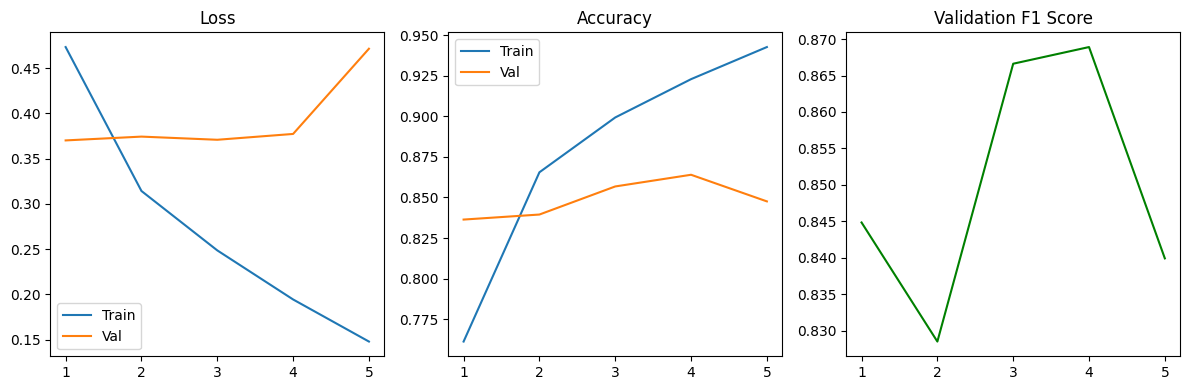

In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

# График Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Train')
plt.plot(epochs_range, history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

# График Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['train_acc'], label='Train')
plt.plot(epochs_range, history['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()

# График F1
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['val_f1'], color='green')
plt.title('Validation F1 Score')

plt.tight_layout()
plt.show()

---


In [16]:
# 1. Загрузка предобученной модели и токенизатора
model_name = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

for param in model.roberta.parameters():
    param.requires_grad = False

# 2. Токенизация (RoBERTa использует BPE токенизацию)
# Используем исходный текст из df['review'], RoBERTa сама справится с регистром
encoded_data = tokenizer(
    df['review'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256, # 256 оптимально для баланса скорости и точности
    return_tensors='pt'
)

labels = torch.tensor(df['sentiment'].values)

# Создание DataLoader
dataset = TensorDataset(encoded_data['input_ids'], encoded_data['attention_mask'], labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8571.35it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# 3. Настройка устройства и оптимизатора
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Для трансформеров рекомендуется очень маленький learning rate
optimizer = AdamW(model.parameters(), lr=2e-5)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'val_f1': []
}

epochs = 3 

# 4. Цикл обучения
for epoch in range(epochs):
    start_time = time.time()
    
    # --- ТРЕНИРОВКА ---
    model.train()
    total_train_loss = 0
    correct_train = 0
    
    # tqdm покажет ETA (время до конца эпохи)
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for batch in train_bar:
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
        
        model.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct_train += (preds == b_labels).sum().item()
        
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # --- ВАЛИДАЦИЯ ---
    model.eval()
    total_val_loss = 0
    correct_val = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            
            total_val_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct_val += (preds == b_labels).sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(b_labels.cpu().numpy())

    # Сбор метрик
    history['train_loss'].append(total_train_loss / len(train_loader))
    history['val_loss'].append(total_val_loss / len(val_loader))
    history['train_acc'].append(correct_train / train_size)
    history['val_acc'].append(correct_val / val_size)
    current_f1 = f1_score(all_labels, all_preds)
    history['val_f1'].append(current_f1)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} | Time: {epoch_time:.2f}s | Val Acc: {history['val_acc'][-1]:.4f} | F1: {current_f1:.4f}")

Epoch 1/3 [Train]: 100%|██████████| 1250/1250 [48:45<00:00,  2.34s/it, loss=0.6119]


Epoch 1 | Time: 3662.61s | Val Acc: 0.8244 | F1: 0.8244


Epoch 2/3 [Train]: 100%|██████████| 1250/1250 [51:05<00:00,  2.45s/it, loss=0.5450]


Epoch 2 | Time: 3893.15s | Val Acc: 0.8341 | F1: 0.8381


Epoch 3/3 [Train]: 100%|██████████| 1250/1250 [52:06<00:00,  2.50s/it, loss=0.5140]


Epoch 3 | Time: 4022.71s | Val Acc: 0.8423 | F1: 0.8463


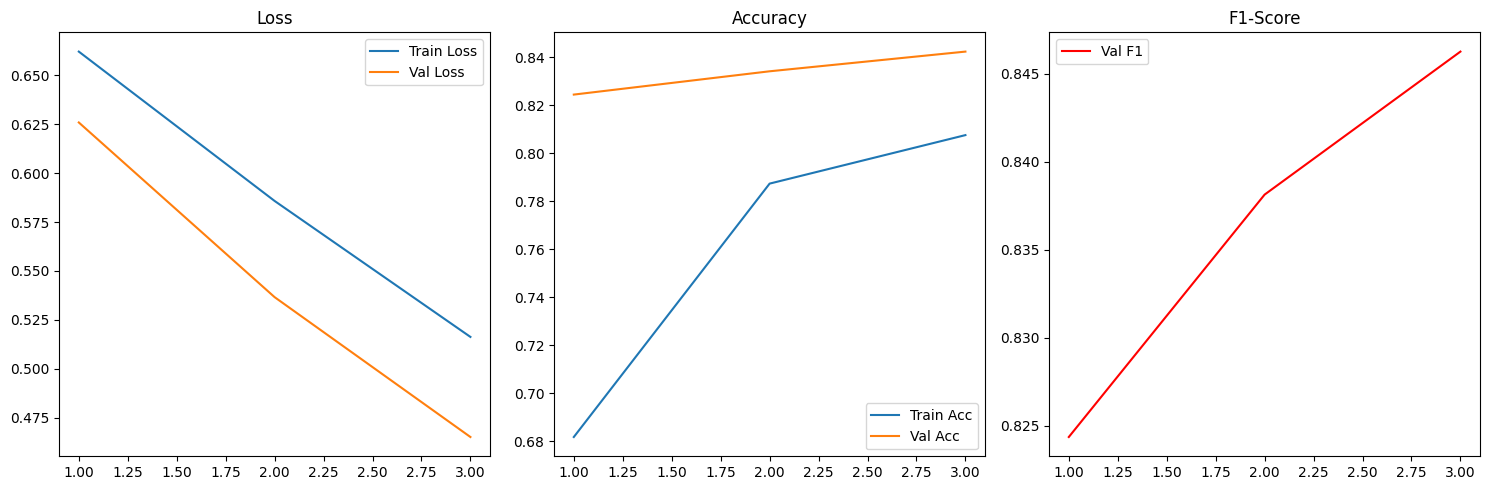

Итоговый F1-Score на валидации: 0.8463


In [19]:
import matplotlib.pyplot as plt
# Построение графиков
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(15, 5))

# График Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

# График Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# График F1
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['val_f1'], color='red', label='Val F1')
plt.title('F1-Score')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговый F1-Score на валидации: {history['val_f1'][-1]:.4f}")